# Mini-Projet : Planification robuste sur grille — A* + Chaînes de Markov
**Objectif** : Planifier un chemin optimal (A*) sur une grille 2D, visualiser les trajectoires réelles stochastiques (succès en vert, échecs en rouge), et évaluer la robustesse via les Chaînes de Markov.

---
## Table des matières
1. Imports et configuration
2. Définition des grilles + chemins A*
3. Planification déterministe (UCS / Greedy / A*)
4. **Visualisation des trajectoires stochastiques (vert = succès / rouge = échec)**
5. Construction de la chaîne de Markov
6. Analyse Markov π^(n)
7. Simulation Monte-Carlo
8. Expériences E.2 et E.4
9. Conclusions

In [41]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

from astar import astar, ucs, greedy, weighted_astar, search, zero_heuristic, get_neighbors
from markov import (build_policy, build_transition_matrix,
                    simulate_trajectories, absorption_analysis)
from grids import GRIDS
print('Modules charges OK')

Modules charges OK


## 2. Grilles et chemins A*

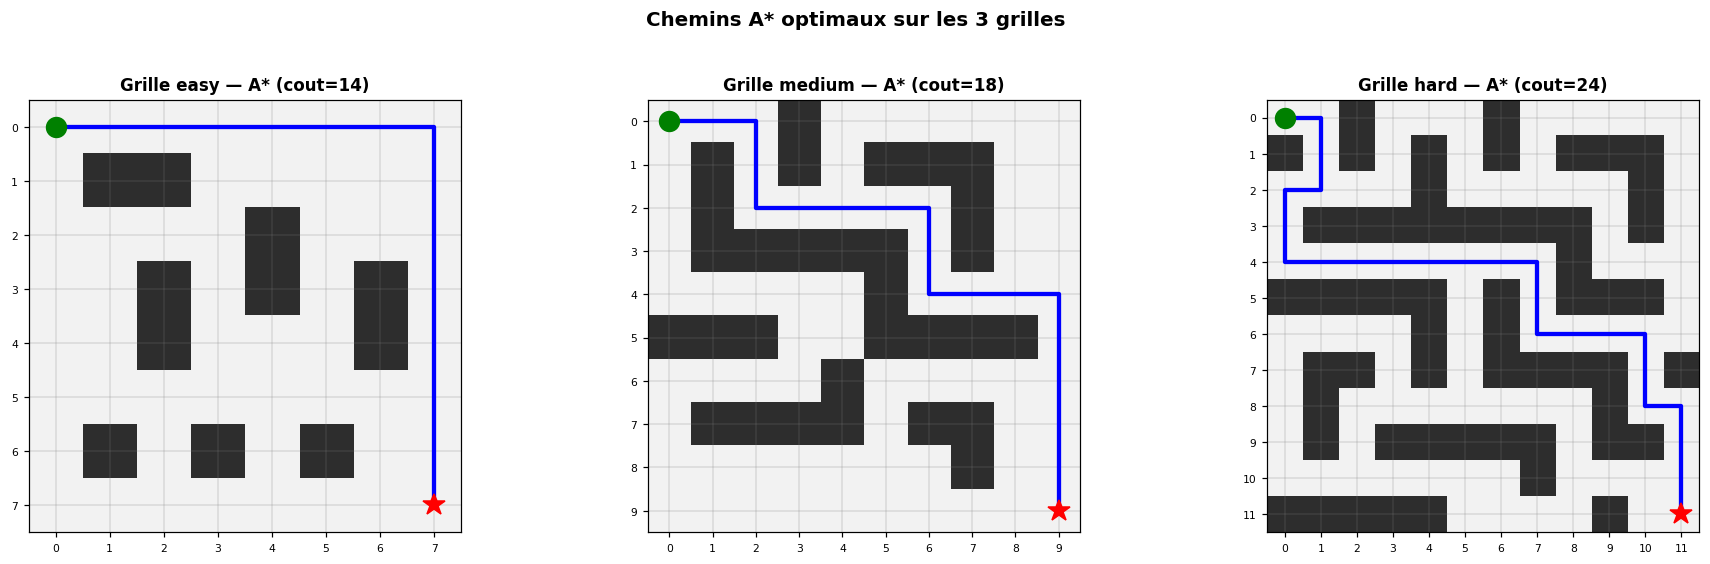

In [42]:
def draw_grid(ax, grid, path=None, start=None, goal=None, title=''):
    rows, cols = len(grid), len(grid[0])
    img = np.array([[1 if grid[r][c]==1 else 0 for c in range(cols)] for r in range(rows)])
    ax.imshow(img, cmap=ListedColormap(['#F2F2F2','#2D2D2D']), vmin=0, vmax=1, zorder=1)
    ax.grid(True, color='gray', lw=0.22, zorder=2)
    if path:
        ax.plot([p[1] for p in path],[p[0] for p in path],'b-',lw=2.8,zorder=4)
    if start: ax.plot(start[1],start[0],'go',ms=13,zorder=5)
    if goal:  ax.plot(goal[1], goal[0], 'r*',ms=15,zorder=5)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
    ax.set_xticklabels(range(cols),fontsize=7); ax.set_yticklabels(range(rows),fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (gname,(grid,start,goal)) in zip(axes, GRIDS.items()):
    r = astar(grid, start, goal)
    draw_grid(ax, grid, r['path'], start, goal,
              title=f'Grille {gname} — A* (cout={r["cost"]:.0f})')
plt.suptitle('Chemins A* optimaux sur les 3 grilles', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Comparaison UCS / Greedy / A*

Grille Algorithme  Cout  Noeuds  OPEN max
  easy        UCS  14.0      53         7
  easy     Greedy  14.0      15         9
  easy         A*  14.0      53         7
medium        UCS  18.0      61         6
medium     Greedy  18.0      19         8
medium         A*  18.0      30         8
  hard        UCS  24.0      87         8
  hard     Greedy  28.0      29         6
  hard         A*  24.0      42         6


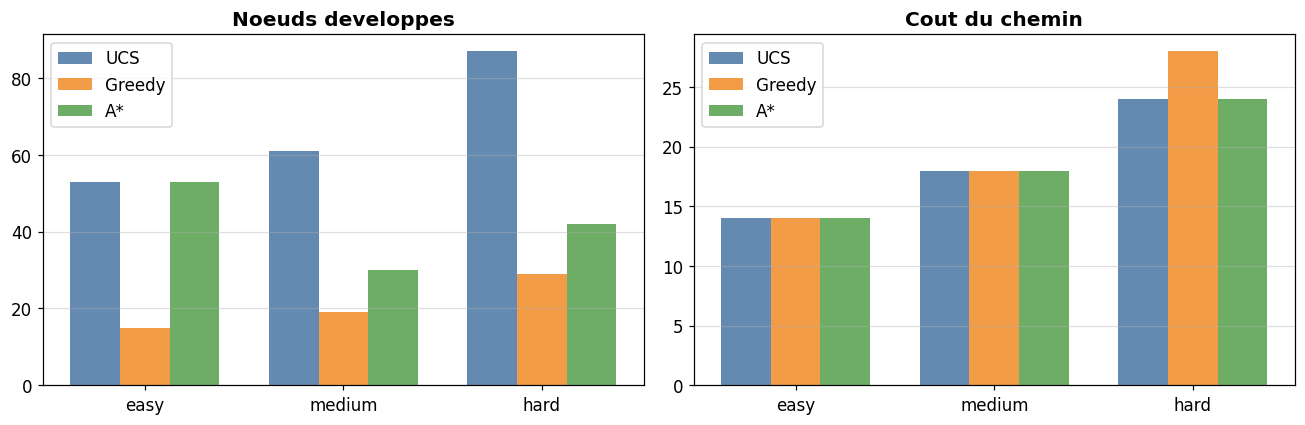

In [43]:
import pandas as pd
algos = {'UCS': ucs, 'Greedy': greedy, 'A*': astar}
rows_data = []
for gname,(grid,start,goal) in GRIDS.items():
    for aname,func in algos.items():
        r = func(grid,start,goal)
        rows_data.append({'Grille':gname,'Algorithme':aname,
            'Cout':r['cost'],'Noeuds':r['nodes_expanded'],'OPEN max':r['open_max_size']})
df = pd.DataFrame(rows_data)
print(df.to_string(index=False))

fig, axes = plt.subplots(1,2,figsize=(12,4))
gnames=list(GRIDS.keys()); x=np.arange(len(gnames)); colors=['#4E79A7','#F28E2B','#59A14F']
for j,(aname,col) in enumerate(zip(algos,colors)):
    vals_n=[df[(df['Algorithme']==aname)&(df['Grille']==g)]['Noeuds'].values[0] for g in gnames]
    vals_c=[df[(df['Algorithme']==aname)&(df['Grille']==g)]['Cout'].values[0] for g in gnames]
    axes[0].bar(x+j*0.25, vals_n, 0.25, label=aname, color=col, alpha=0.87)
    axes[1].bar(x+j*0.25, vals_c, 0.25, label=aname, color=col, alpha=0.87)
for ax,title in zip(axes,['Noeuds developpes','Cout du chemin']):
    ax.set_xticks(x+0.25); ax.set_xticklabels(gnames)
    ax.set_title(title,fontweight='bold'); ax.legend(); ax.grid(axis='y',alpha=0.4)
plt.tight_layout(); plt.show()

## 4. Visualisation des trajectoires stochastiques

On simule des trajectoires **réelles** de l'agent sous incertitude ε :
- 🔵 **Chemin A*** (bleu épais) : plan déterministe optimal
- 🟢 **Trajectoires réussies** (vert semi-transparent) : l'agent atteint GOAL malgré les déviations
- 🔴 **Trajectoires échouées** (rouge semi-transparent) : l'agent se perd et n'atteint pas le but

Chaque ligne fine = 1 trajectoire différente de l'agent réel.

In [44]:
def simulate_full_trajectories(P, state_to_idx, start, goal, n_traj=50, max_steps=150, seed=42):
    """Retourne les trajectoires completes (liste de positions) classees succes/echec."""
    idx_to_state = {v: k for k,v in state_to_idx.items()}
    start_idx = state_to_idx.get(start)
    goal_idx  = state_to_idx.get(goal)
    n = P.shape[0]
    P_cum = np.cumsum(P, axis=1)
    rng = np.random.default_rng(seed)
    success_paths, fail_paths = [], []
    for _ in range(n_traj):
        state = start_idx
        traj  = [idx_to_state[state]]
        reached = False
        for _ in range(max_steps):
            nxt = int(np.searchsorted(P_cum[state], rng.random()))
            state = min(nxt, n-1)
            s = idx_to_state.get(state)
            if s is None: break
            traj.append(s)
            if state == goal_idx:
                reached = True; break
        (success_paths if reached else fail_paths).append(traj)
    return success_paths, fail_paths

print('simulate_full_trajectories definie OK')

simulate_full_trajectories definie OK


### 4.1 Grille medium — comparaison de 3 valeurs de ε

On fixe A* sur la **grille moyenne** (coût optimal = 18) et on simule **50 trajectoires** pour chaque valeur de ε ∈ {0.1, 0.2, 0.3}.

Chaque trajectoire est classée :
- 🔵 **Plan A*** (bleu épais) — chemin déterministe optimal
- 🟢 **Trajectoire réussie** (vert) — l'agent atteint GOAL malgré les déviations aléatoires
- 🔴 **Trajectoire échouée** (rouge) — l'agent se perd et dépasse `max_steps` sans atteindre le but

> **Observation attendue** : plus ε augmente, plus les lignes rouges apparaissent et les vertes disparaissent — le plan devient fragile.

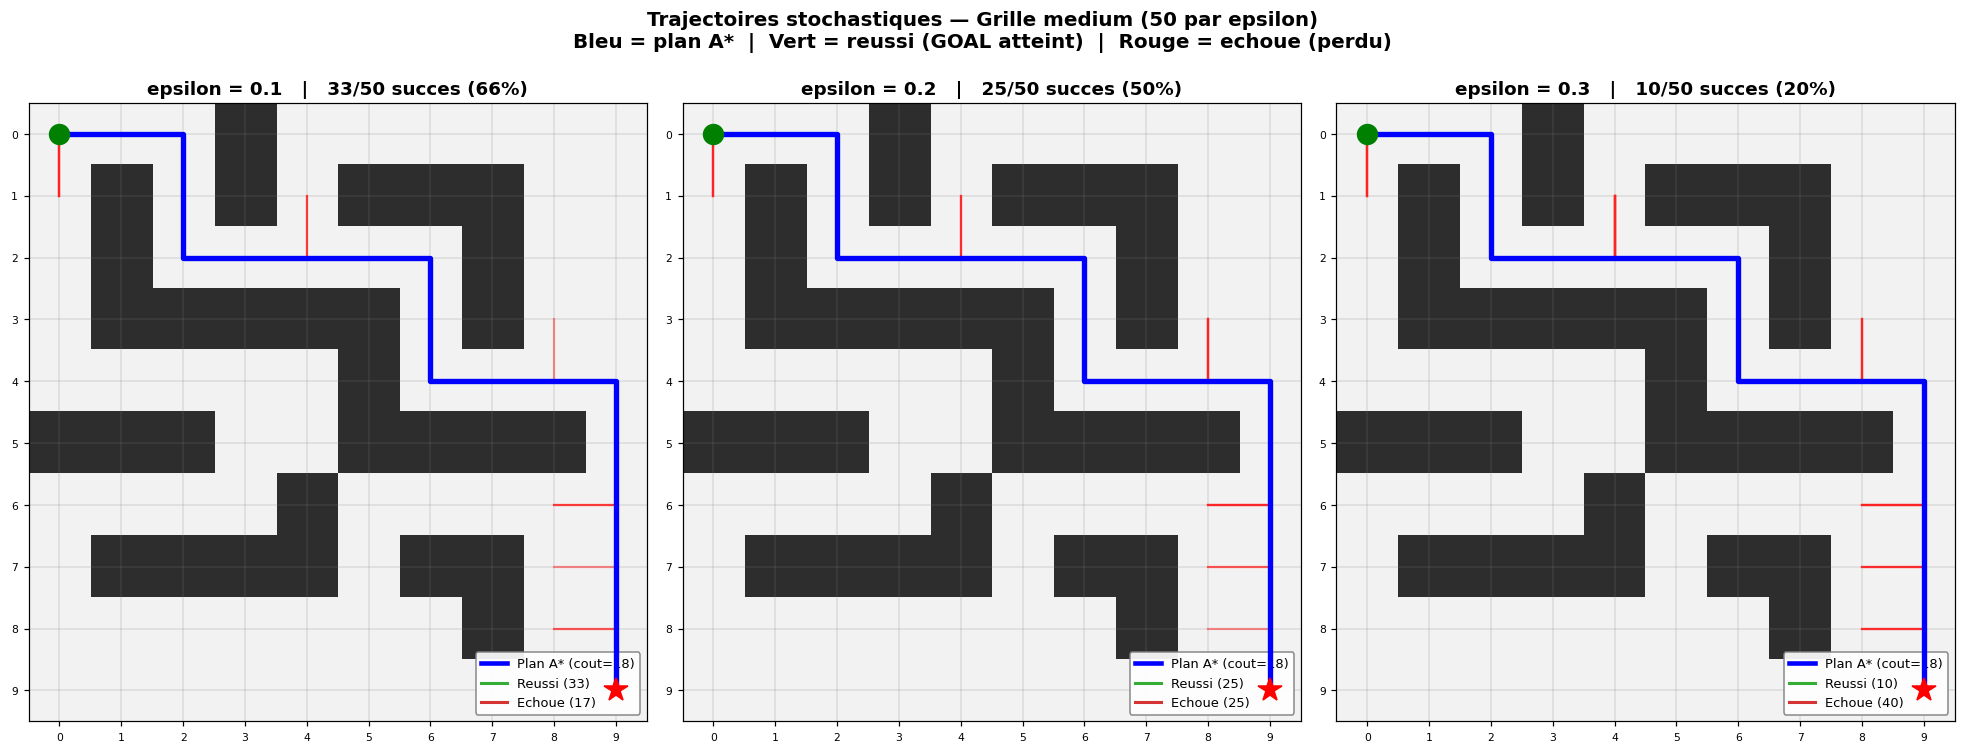

In [45]:
grid, start, goal = GRIDS['medium']
r_astar = astar(grid, start, goal)
path_astar = r_astar['path']
policy = build_policy(path_astar)

accessible = list({s for s in path_astar})
for s in path_astar:
    for nb,_ in get_neighbors(s, grid):
        if nb not in accessible: accessible.append(nb)

N_TRAJ = 50
EPSILONS = [0.1, 0.2, 0.3]
rows, cols = len(grid), len(grid[0])
img = np.array([[1 if grid[r][c]==1 else 0 for c in range(cols)] for r in range(rows)])

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))

for ax, eps in zip(axes, EPSILONS):
    P, s2i = build_transition_matrix(accessible, policy, goal, grid, epsilon=eps)
    succ, fail = simulate_full_trajectories(P, s2i, start, goal, n_traj=N_TRAJ, max_steps=150)

    ax.imshow(img, cmap=ListedColormap(['#F2F2F2','#2D2D2D']), vmin=0, vmax=1, zorder=1)
    ax.grid(True, color='gray', lw=0.2, zorder=2)

    # Trajectoires echouees en rouge
    for traj in fail:
        ax.plot([p[1] for p in traj],[p[0] for p in traj],
                color='#FF2222', alpha=0.50, lw=1.4, zorder=3)
    # Trajectoires reussies en vert
    for traj in succ:
        ax.plot([p[1] for p in traj],[p[0] for p in traj],
                color='#00CC00', alpha=0.50, lw=1.4, zorder=3)

    # Plan A* en bleu par-dessus tout
    ax.plot([p[1] for p in path_astar],[p[0] for p in path_astar],
            'b-', lw=3.5, zorder=6)
    ax.plot(start[1],start[0],'go',ms=13,zorder=7)
    ax.plot(goal[1], goal[0], 'r*',ms=16,zorder=7)

    pct = len(succ)/N_TRAJ*100
    ax.set_title(f'epsilon = {eps}   |   {len(succ)}/{N_TRAJ} succes ({pct:.0f}%)',
                 fontweight='bold', fontsize=12)
    ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
    ax.set_xticklabels(range(cols),fontsize=7); ax.set_yticklabels(range(rows),fontsize=7)

    legend_elements = [
        Line2D([0],[0],color='blue',    lw=3,  label=f'Plan A* (cout={r_astar["cost"]:.0f})'),
        Line2D([0],[0],color='#009900', lw=2,  alpha=0.8, label=f'Reussi ({len(succ)})'),
        Line2D([0],[0],color='#CC0000', lw=2,  alpha=0.8, label=f'Echoue ({len(fail)})'),
    ]
    ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right',
              framealpha=0.92, edgecolor='gray')

plt.suptitle(
    f'Trajectoires stochastiques — Grille medium ({N_TRAJ} par epsilon)\n'
    'Bleu = plan A*  |  Vert = reussi (GOAL atteint)  |  Rouge = echoue (perdu)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout(); plt.show()

### 4.2 Les 3 grilles avec ε = 0.2 — trajectoires + densité

On fixe ε = 0.2 (20% de chance de déviation à chaque pas) et on simule **40 trajectoires** sur les 3 grilles.

**Ligne du haut — trajectoires individuelles :**
- 🟢 **Vert** = trajectoire réussie : l'agent suit approximativement le plan A* avec quelques déviations et finit par atteindre GOAL
- 🔴 **Rouge** = trajectoire échouée : l'agent dévie latéralement dès les premiers pas, se retrouve dans une zone sans issue et tourne en boucle jusqu'à `max_steps`
- 🔵 **Bleu pointillé** = plan A* optimal (rendu fin pour ne pas masquer les trajectoires vertes)

**Ligne du bas — heatmap de densité :**
- Les **zones vertes** = là où passent les agents *qui réussissent* → ils restent proches du chemin A*
- Les **zones rouges** = là où s'accumulent les agents *qui échouent* → révèle les **pièges** de la grille

> **Pourquoi les rouges semblent courts et aléatoires ?** C'est normal : l'échec arrive très tôt (1-3 pas). L'agent part du coin haut-gauche dans un corridor étroit — une seule déviation latérale le sort du chemin et le bloque contre un obstacle où il boucle indéfiniment. La heatmap rouge en bas le confirme : les échecs se concentrent toujours aux mêmes endroits dangereux.

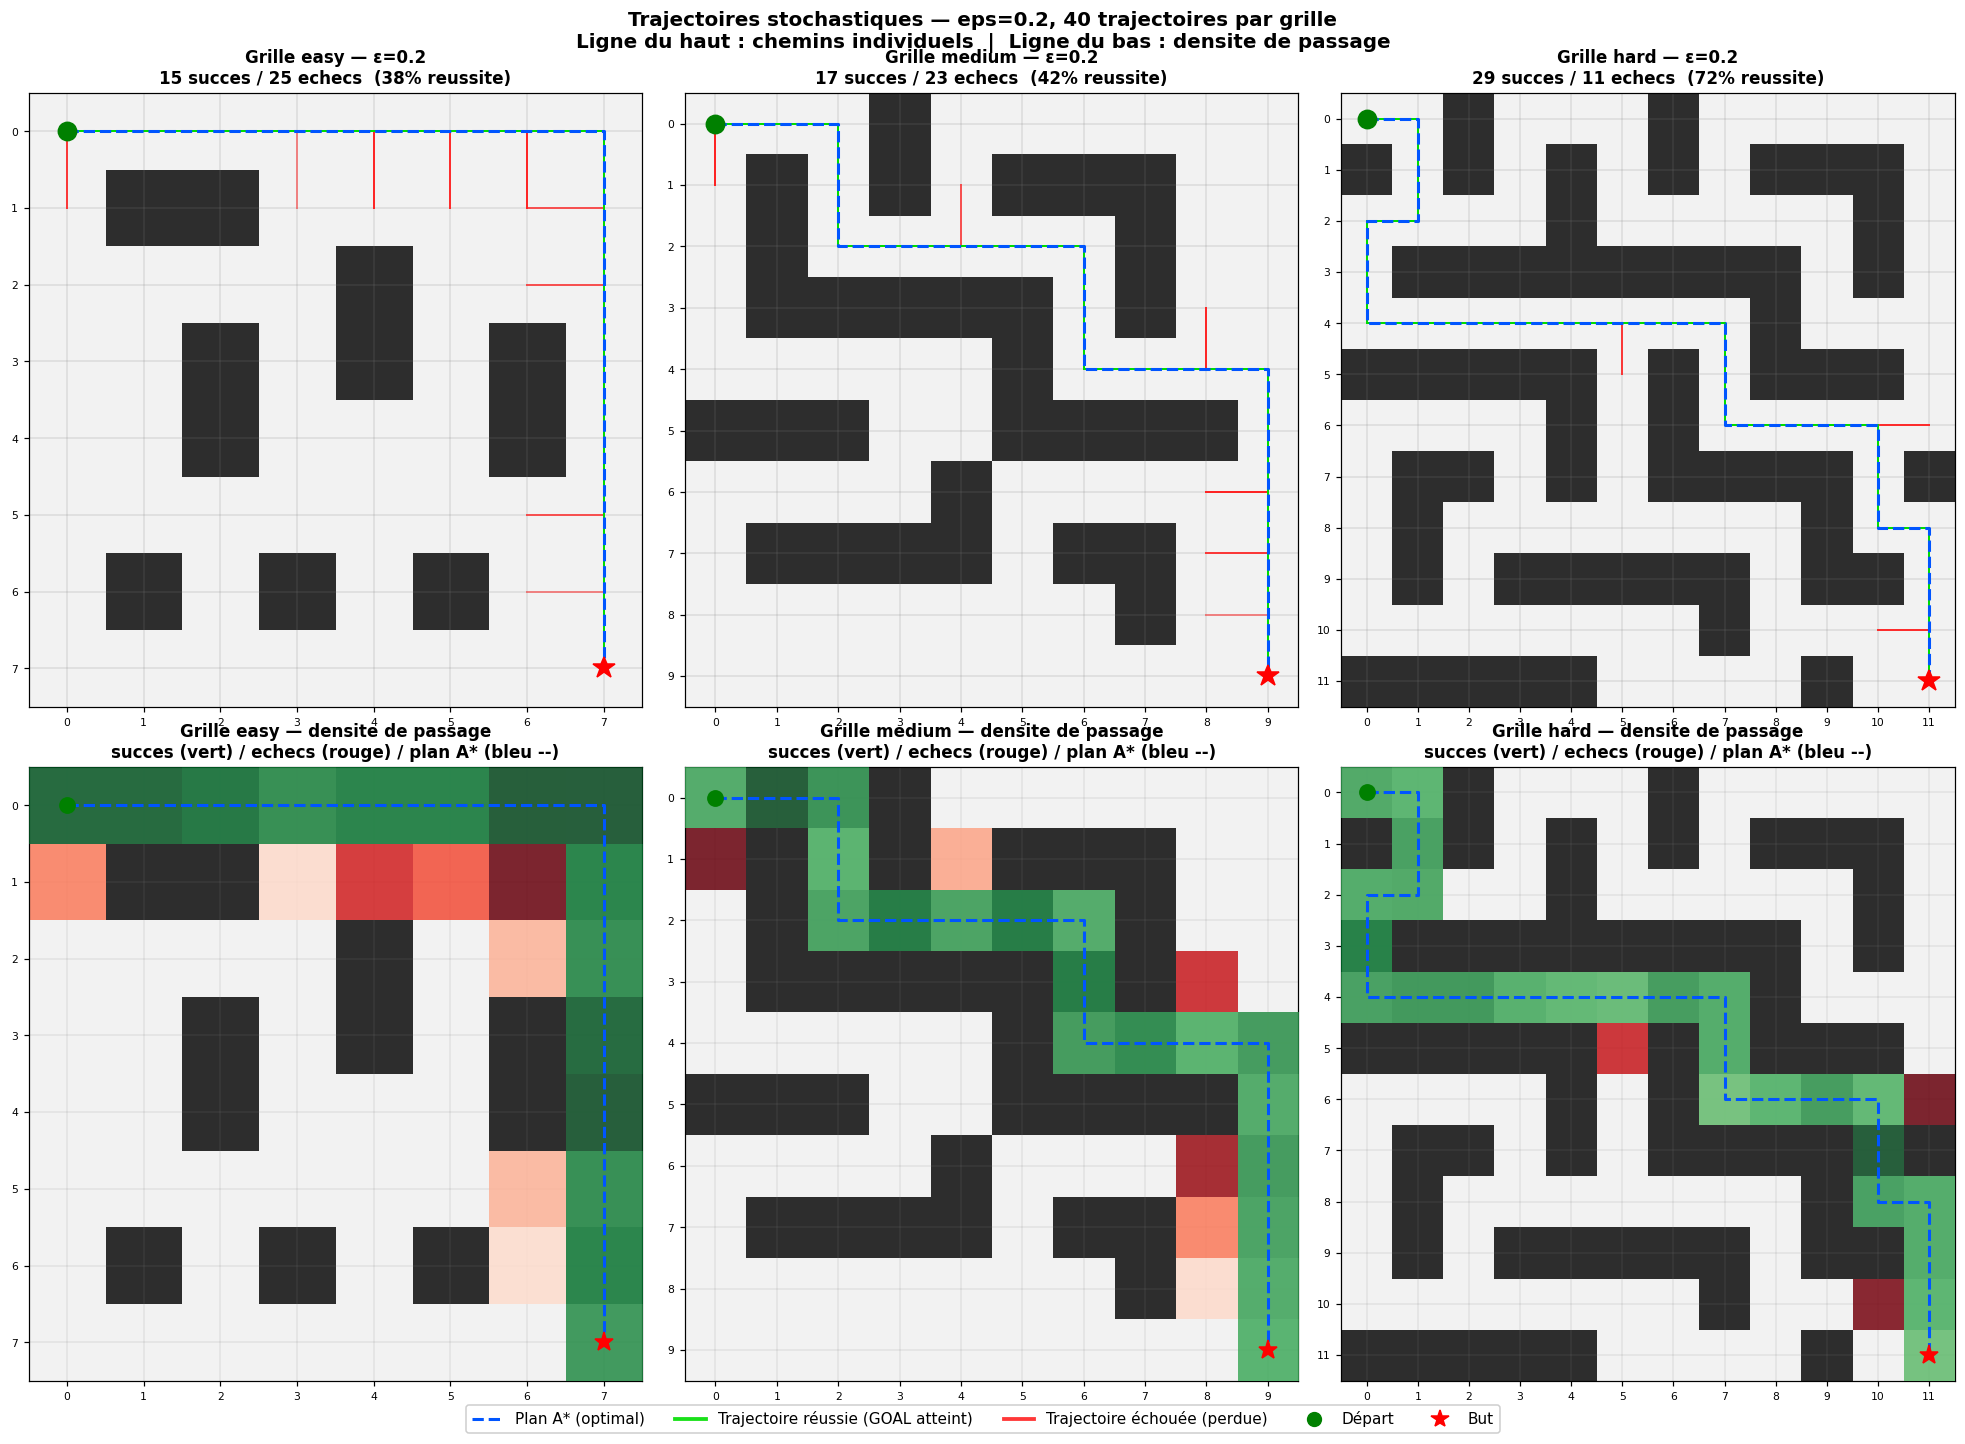

In [46]:
EPS = 0.2
N2  = 40
fig, axes = plt.subplots(2, 3, figsize=(18, 13))
axes_top = axes[0]   # trajectoires
axes_bot = axes[1]   # heatmaps

for col, (gname,(grid,start,goal)) in enumerate(GRIDS.items()):
    r_a = astar(grid, start, goal)
    path_a = r_a['path']
    pol = build_policy(path_a)
    acc = list({s for s in path_a})
    for s in path_a:
        for nb,_ in get_neighbors(s,grid):
            if nb not in acc: acc.append(nb)
    P, s2i = build_transition_matrix(acc, pol, goal, grid, epsilon=EPS)
    succ, fail = simulate_full_trajectories(P, s2i, start, goal, n_traj=N2, max_steps=200)

    rows,cols = len(grid),len(grid[0])
    img = np.array([[1 if grid[r][c]==1 else 0 for c in range(cols)] for r in range(rows)])
    mask = np.array([[grid[r][c]==1 for c in range(cols)] for r in range(rows)])

    # ── Ligne du haut : trajectoires individuelles ────────────────────────────
    ax = axes_top[col]
    ax.imshow(img, cmap=ListedColormap(['#F2F2F2','#2D2D2D']), vmin=0, vmax=1, zorder=1)
    ax.grid(True, color='gray', lw=0.2, zorder=2)

    # Echecs en rouge — affichés EN PREMIER (derrière)
    for traj in fail:
        ax.plot([p[1] for p in traj],[p[0] for p in traj],
                color='#FF2222', alpha=0.50, lw=1.3, zorder=3)
    # Succes en vert — affichés AU-DESSUS des rouges
    for traj in succ:
        ax.plot([p[1] for p in traj],[p[0] for p in traj],
                color='#00DD00', alpha=0.60, lw=1.3, zorder=4)

    # Plan A* en bleu fin (pas épais) pour ne pas masquer les verts
    ax.plot([p[1] for p in path_a],[p[0] for p in path_a],
            color='#0055FF', lw=2.0, ls='--', zorder=5, label='Plan A*')
    ax.plot(start[1],start[0],'go',ms=12,zorder=7)
    ax.plot(goal[1], goal[0], 'r*',ms=15,zorder=7)

    pct = len(succ)/N2*100
    ax.set_title(f'Grille {gname} — ε={EPS}\n'
                 f'{len(succ)} succes / {len(fail)} echecs  ({pct:.0f}% reussite)',
                 fontweight='bold', fontsize=11)
    ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
    ax.set_xticklabels(range(cols),fontsize=7)
    ax.set_yticklabels(range(rows),fontsize=7)

    # ── Ligne du bas : heatmaps ───────────────────────────────────────────────
    # Construire heatmaps depuis TOUTES les trajectoires
    hm_s = np.zeros((rows,cols))
    hm_f = np.zeros((rows,cols))
    for traj in succ:
        for (r,c) in traj: hm_s[r,c] += 1
    for traj in fail:
        for (r,c) in traj: hm_f[r,c] += 1

    ax2 = axes_bot[col]
    # Fond obstacles
    ax2.imshow(img, cmap=ListedColormap(['#F2F2F2','#2D2D2D']), vmin=0, vmax=1, zorder=1)

    # Heatmap rouge (echecs) en dessous
    hm_f_masked = np.ma.masked_where(mask | (hm_f==0), hm_f)
    ax2.imshow(hm_f_masked, cmap='Reds', alpha=0.85, zorder=2,
               vmin=0, vmax=max(hm_f.max(), 1))

    # Heatmap verte (succes) par-dessus
    hm_s_masked = np.ma.masked_where(mask | (hm_s==0), hm_s)
    im = ax2.imshow(hm_s_masked, cmap='Greens', alpha=0.85, zorder=3,
                    vmin=0, vmax=max(hm_s.max(), 1))

    # Plan A* par-dessus tout
    ax2.plot([p[1] for p in path_a],[p[0] for p in path_a],
             color='#0055FF', lw=2.0, ls='--', zorder=6)
    ax2.plot(start[1],start[0],'go',ms=10,zorder=7)
    ax2.plot(goal[1], goal[0],'r*',ms=13,zorder=7)
    ax2.set_title(f'Grille {gname} — densite de passage\nsucces (vert) / echecs (rouge) / plan A* (bleu --)',
                  fontweight='bold', fontsize=11)
    ax2.set_xticks(range(cols)); ax2.set_yticks(range(rows))
    ax2.set_xticklabels(range(cols),fontsize=7)
    ax2.set_yticklabels(range(rows),fontsize=7)
    ax2.grid(True, color='gray', lw=0.15, zorder=4)

# Légende commune (ligne du haut)
legend_els = [
    Line2D([0],[0],color='#0055FF', lw=2, ls='--', label='Plan A* (optimal)'),
    Line2D([0],[0],color='#00DD00', lw=2.5, alpha=0.9, label='Trajectoire réussie (GOAL atteint)'),
    Line2D([0],[0],color='#FF2222', lw=2.5, alpha=0.9, label='Trajectoire échouée (perdue)'),
    Line2D([0],[0],marker='o',color='g',ms=9,lw=0,label='Départ'),
    Line2D([0],[0],marker='*',color='r',ms=12,lw=0,label='But'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=5,
           fontsize=10, framealpha=0.95, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Trajectoires stochastiques — eps={EPS}, {N2} trajectoires par grille\nLigne du haut : chemins individuels  |  Ligne du bas : densite de passage',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.3 Heatmap de densité de passage — Grille difficile, ε = 0.25, 300 trajectoires

On simule 300 trajectoires et on compte, **pour chaque cellule**, combien de fois l'agent y est passé — séparément pour les succès et les échecs.

**Trois panneaux :**
- **Gauche** — 40 trajectoires individuelles superposées (pour visualiser les chemins bruts)
- **Centre (vert)** — densité de passage des trajectoires **réussies** : l'intensité montre où passent les agents qui atteignent GOAL. On voit qu'ils suivent de près le chemin A* (bleu).
- **Droite (rouge)** — densité de passage des trajectoires **échouées** : révèle les **zones pièges** — les cellules où les agents se bloquent en boucle. Les points chauds correspondent aux corridors étroits perpendiculaires au chemin optimal.

> **Interprétation** : la heatmap rouge identifie précisément les zones de la grille les plus dangereuses sous incertitude — information utile pour une re-planification ou un MDP ciblé.

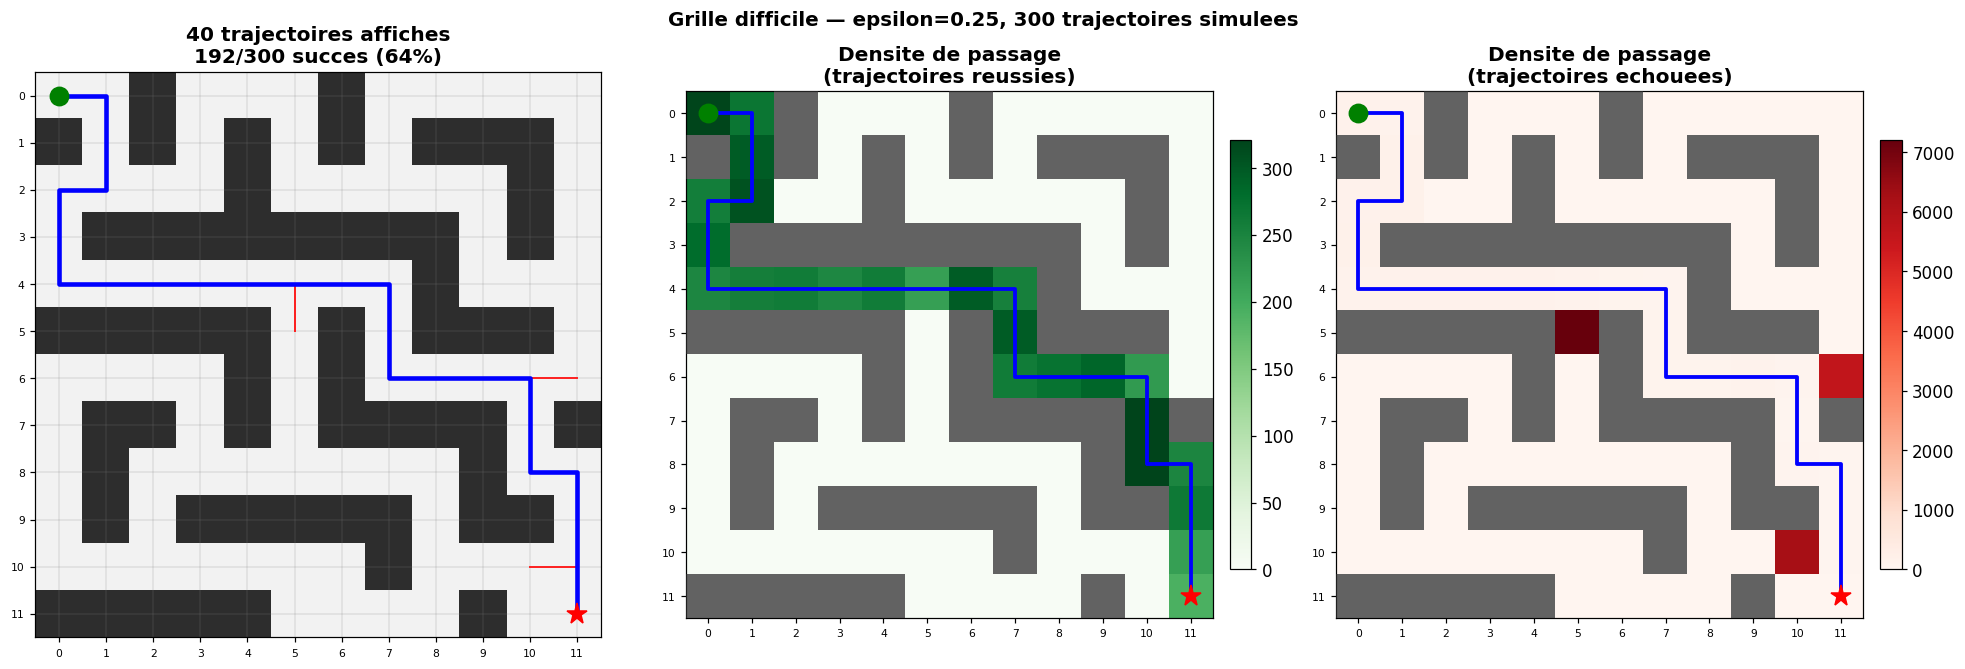

Succes : 192/300  |  Echecs : 108/300


In [47]:
grid, start, goal = GRIDS['hard']
r_a = astar(grid, start, goal); path_a = r_a['path']
pol = build_policy(path_a)
acc = list({s for s in path_a})
for s in path_a:
    for nb,_ in get_neighbors(s,grid):
        if nb not in acc: acc.append(nb)

EPS_H = 0.25
P, s2i = build_transition_matrix(acc, pol, goal, grid, epsilon=EPS_H)
succ_h, fail_h = simulate_full_trajectories(P, s2i, start, goal, n_traj=300, max_steps=200)

rows, cols = len(grid), len(grid[0])
hm_s = np.zeros((rows,cols)); hm_f = np.zeros((rows,cols))
for traj in succ_h:
    for (r,c) in traj: hm_s[r,c] += 1
for traj in fail_h:
    for (r,c) in traj: hm_f[r,c] += 1

img = np.array([[1 if grid[r][c]==1 else 0 for c in range(cols)] for r in range(rows)])
mask = np.array([[grid[r][c]==1 for c in range(cols)] for r in range(rows)])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# -- Panneau 1 : trajectoires brutes (40 affiches)
ax = axes[0]
ax.imshow(img, cmap=ListedColormap(['#F2F2F2','#2D2D2D']), vmin=0, vmax=1, zorder=1)
ax.grid(True, color='gray', lw=0.18, zorder=2)
for traj in fail_h[:40]:
    ax.plot([p[1] for p in traj],[p[0] for p in traj],'#FF2222',alpha=0.35,lw=1.0,zorder=3)
for traj in succ_h[:40]:
    ax.plot([p[1] for p in traj],[p[0] for p in traj],'#00CC00',alpha=0.40,lw=1.0,zorder=3)
ax.plot([p[1] for p in path_a],[p[0] for p in path_a],'b-',lw=3,zorder=6)
ax.plot(start[1],start[0],'go',ms=12,zorder=7); ax.plot(goal[1],goal[0],'r*',ms=14,zorder=7)
pct = len(succ_h)/300*100
ax.set_title(f'40 trajectoires affiches\n{len(succ_h)}/300 succes ({pct:.0f}%)',fontweight='bold')
ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
ax.set_xticklabels(range(cols),fontsize=7); ax.set_yticklabels(range(rows),fontsize=7)

# -- Panneau 2 : heatmap succes
ax = axes[1]
im = ax.imshow(np.ma.masked_where(mask,hm_s), cmap='Greens', zorder=2)
ax.imshow(img, cmap=ListedColormap(['none','#2D2D2D']), vmin=0, vmax=1, zorder=3, alpha=0.75)
ax.plot([p[1] for p in path_a],[p[0] for p in path_a],'b-',lw=2.5,zorder=6)
ax.plot(start[1],start[0],'go',ms=12,zorder=7); ax.plot(goal[1],goal[0],'r*',ms=14,zorder=7)
plt.colorbar(im, ax=ax, fraction=0.038, pad=0.03)
ax.set_title('Densite de passage\n(trajectoires reussies)', fontweight='bold')
ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
ax.set_xticklabels(range(cols),fontsize=7); ax.set_yticklabels(range(rows),fontsize=7)

# -- Panneau 3 : heatmap echecs
ax = axes[2]
im2 = ax.imshow(np.ma.masked_where(mask,hm_f), cmap='Reds', zorder=2)
ax.imshow(img, cmap=ListedColormap(['none','#2D2D2D']), vmin=0, vmax=1, zorder=3, alpha=0.75)
ax.plot([p[1] for p in path_a],[p[0] for p in path_a],'b-',lw=2.5,zorder=6)
ax.plot(start[1],start[0],'go',ms=12,zorder=7); ax.plot(goal[1],goal[0],'r*',ms=14,zorder=7)
plt.colorbar(im2, ax=ax, fraction=0.038, pad=0.03)
ax.set_title('Densite de passage\n(trajectoires echouees)', fontweight='bold')
ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
ax.set_xticklabels(range(cols),fontsize=7); ax.set_yticklabels(range(rows),fontsize=7)

plt.suptitle(f'Grille difficile — epsilon={EPS_H}, 300 trajectoires simulees',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Succes : {len(succ_h)}/300  |  Echecs : {len(fail_h)}/300')

## 5. Construction de la chaîne de Markov

In [48]:
grid, start, goal = GRIDS['medium']
r = astar(grid, start, goal); path = r['path']
policy = build_policy(path)
accessible = list({s for s in path})
for s in path:
    for nb,_ in get_neighbors(s,grid):
        if nb not in accessible: accessible.append(nb)

epsilon = 0.2
P, state_to_idx = build_transition_matrix(accessible, policy, goal, grid, epsilon=epsilon)
print(f'Matrice P : {P.shape[0]} etats')
print(f'Stochastique (somme lignes = 1) : {np.allclose(P.sum(axis=1), 1.0)}')
print(f'Chemin A* : {len(path)} etats, cout = {r["cost"]}')

Matrice P : 27 etats
Stochastique (somme lignes = 1) : True
Chemin A* : 19 etats, cout = 18.0


## 6. Analyse Markov — π^(n)

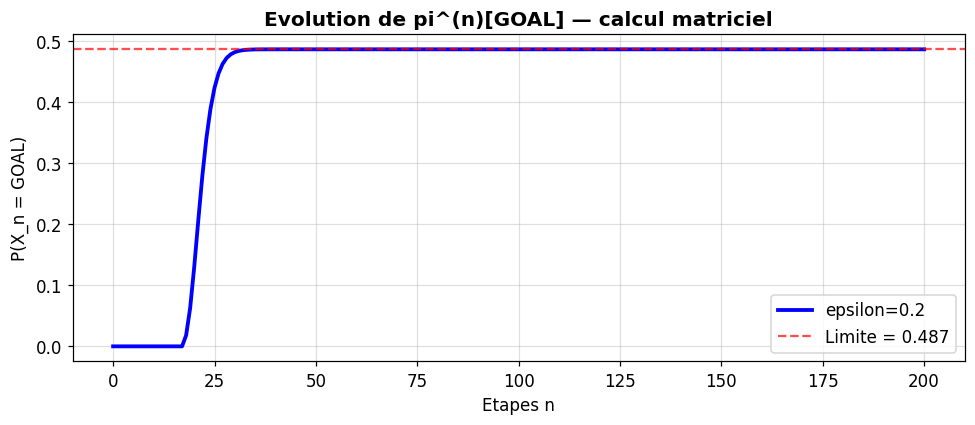

P(GOAL a n=200) = 0.4865


In [49]:
n_states = P.shape[0]
goal_idx = state_to_idx[goal]; start_idx = state_to_idx[start]
pi0 = np.zeros(n_states); pi0[start_idx] = 1.0

steps_range = list(range(0, 100)) + list(range(100, 201, 5))
prob_goal_over_time = []
Pn = np.eye(n_states); prev = 0
for n_step in steps_range:
    for _ in range(n_step - prev): Pn = Pn @ P
    prob_goal_over_time.append((pi0 @ Pn)[goal_idx])
    prev = n_step

plt.figure(figsize=(9, 4))
plt.plot(steps_range, prob_goal_over_time, 'b-', lw=2.5, label=f'epsilon={epsilon}')
plt.axhline(prob_goal_over_time[-1], color='red', ls='--', alpha=0.7,
            label=f'Limite = {prob_goal_over_time[-1]:.3f}')
plt.xlabel('Etapes n'); plt.ylabel('P(X_n = GOAL)')
plt.title('Evolution de pi^(n)[GOAL] — calcul matriciel', fontweight='bold')
plt.grid(alpha=0.4); plt.legend(); plt.tight_layout(); plt.show()
print(f'P(GOAL a n=200) = {prob_goal_over_time[-1]:.4f}')

## 7. Simulation Monte-Carlo

P(GOAL) simulation  = 0.4815
P(GOAL) matriciel   = 0.4865
Temps moyen (sim)   = 22.36 etapes
Taux echec          = 0.5185


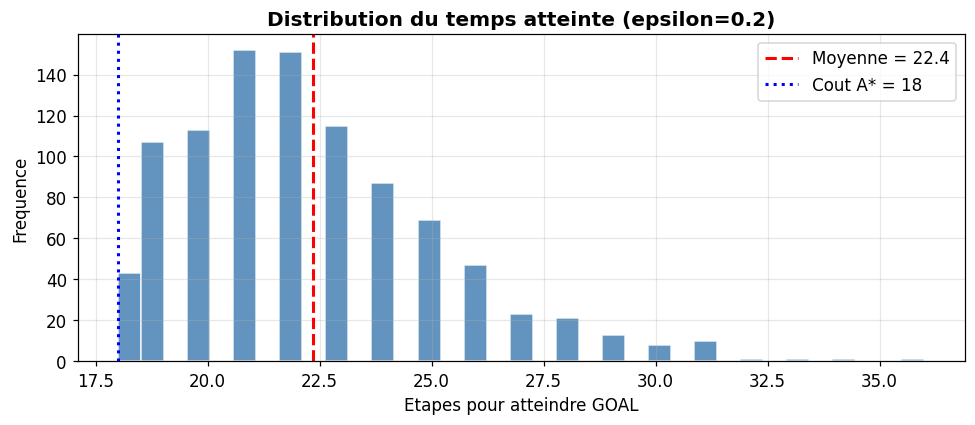

In [50]:
sim = simulate_trajectories(P, state_to_idx, start, goal, n_traj=2000, max_steps=200)
print(f'P(GOAL) simulation  = {sim["prob_goal"]:.4f}')
print(f'P(GOAL) matriciel   = {prob_goal_over_time[-1]:.4f}')
print(f'Temps moyen (sim)   = {sim["mean_time"]:.2f} etapes')
print(f'Taux echec          = {sim["fail_rate"]:.4f}')

if sim['reach_times']:
    plt.figure(figsize=(9, 4))
    plt.hist(sim['reach_times'], bins=35, color='steelblue', alpha=0.85, edgecolor='white')
    plt.axvline(np.mean(sim['reach_times']), color='red', ls='--', lw=2,
                label=f'Moyenne = {sim["mean_time"]:.1f}')
    plt.axvline(r['cost'], color='blue', ls=':', lw=2,
                label=f'Cout A* = {r["cost"]:.0f}')
    plt.xlabel('Etapes pour atteindre GOAL'); plt.ylabel('Frequence')
    plt.title(f'Distribution du temps atteinte (epsilon={epsilon})', fontweight='bold')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Expériences E.2 et E.4

epsilon=0.0 | P(GOAL)=1.000 | t_moy=18.0
epsilon=0.1 | P(GOAL)=0.743 | t_moy=19.9
epsilon=0.2 | P(GOAL)=0.481 | t_moy=22.4
epsilon=0.3 | P(GOAL)=0.302 | t_moy=25.4


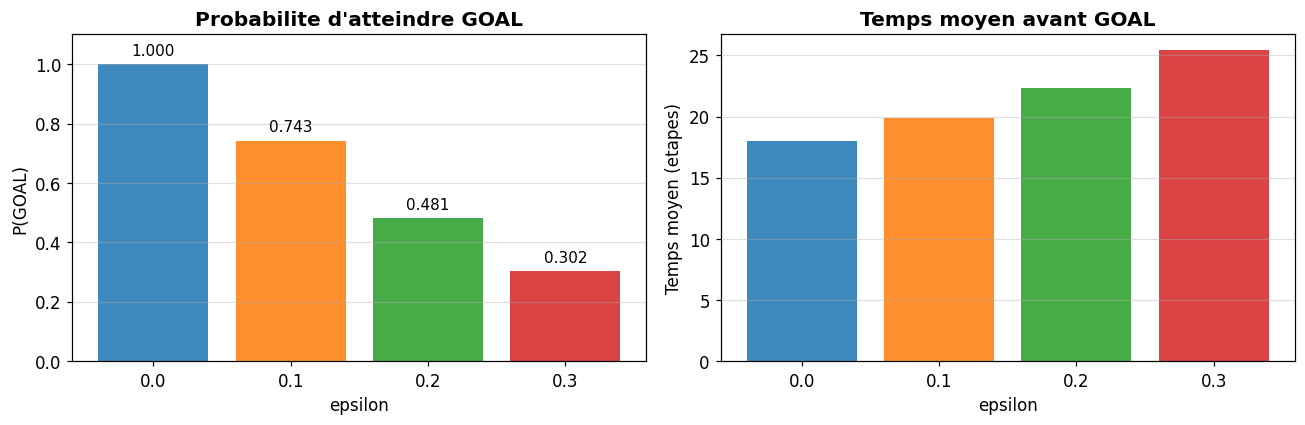

In [51]:
# E.2 : variation de epsilon
epsilons = [0.0, 0.1, 0.2, 0.3]
e2 = {}
for eps in epsilons:
    P_e, s2i_e = build_transition_matrix(accessible, policy, goal, grid, epsilon=eps)
    sim_e = simulate_trajectories(P_e, s2i_e, start, goal, n_traj=2000, max_steps=200)
    e2[eps] = sim_e
    print(f'epsilon={eps:.1f} | P(GOAL)={sim_e["prob_goal"]:.3f} | t_moy={sim_e["mean_time"]:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
axes[0].bar([str(e) for e in epsilons],[e2[e]['prob_goal'] for e in epsilons],color=colors,alpha=0.87)
axes[0].set_xlabel('epsilon'); axes[0].set_ylabel('P(GOAL)')
axes[0].set_title("Probabilite d'atteindre GOAL",fontweight='bold')
axes[0].set_ylim(0,1.1); axes[0].grid(axis='y',alpha=0.4)
for i,e in enumerate(epsilons):
    v=e2[e]['prob_goal']; axes[0].text(i,v+0.03,f'{v:.3f}',ha='center',fontsize=10)

mt=[e2[e]['mean_time'] if e2[e]['mean_time']!=float('inf') else 0 for e in epsilons]
axes[1].bar([str(e) for e in epsilons],mt,color=colors,alpha=0.87)
axes[1].set_xlabel('epsilon'); axes[1].set_ylabel('Temps moyen (etapes)')
axes[1].set_title('Temps moyen avant GOAL',fontweight='bold'); axes[1].grid(axis='y',alpha=0.4)
plt.tight_layout(); plt.show()

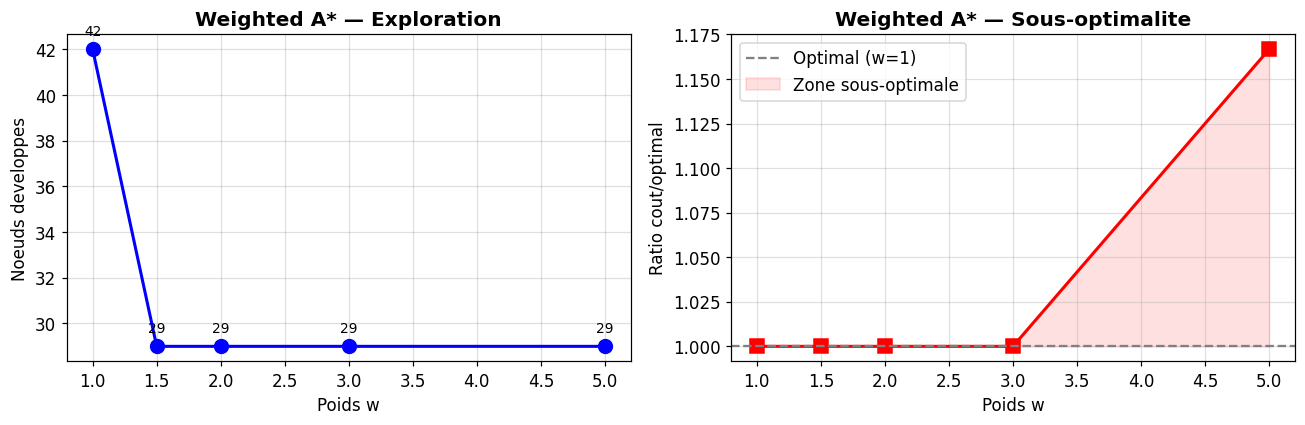

In [52]:
# E.4 : Weighted A*
grid_h, start_h, goal_h = GRIDS['hard']
weights = [1.0, 1.5, 2.0, 3.0, 5.0]
wa = {w: weighted_astar(grid_h, start_h, goal_h, w) for w in weights}
opt = wa[1.0]['cost']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weights,[wa[w]['nodes_expanded'] for w in weights],'bo-',lw=2,ms=9)
for w in weights:
    axes[0].annotate(str(wa[w]['nodes_expanded']),(w,wa[w]['nodes_expanded']),
                     textcoords='offset points',xytext=(0,9),ha='center',fontsize=9)
axes[0].set_xlabel('Poids w'); axes[0].set_ylabel('Noeuds developpes')
axes[0].set_title('Weighted A* — Exploration',fontweight='bold'); axes[0].grid(alpha=0.4)

ratios=[wa[w]['cost']/opt for w in weights]
axes[1].plot(weights,ratios,'rs-',lw=2,ms=9)
axes[1].axhline(1.0,color='gray',ls='--',label='Optimal (w=1)')
axes[1].fill_between(weights,1.0,ratios,alpha=0.12,color='red',label='Zone sous-optimale')
axes[1].set_xlabel('Poids w'); axes[1].set_ylabel('Ratio cout/optimal')
axes[1].set_title('Weighted A* — Sous-optimalite',fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()

## 9. Conclusions

- **A*** garantit l'optimalité via Manhattan admissible, réduit l'exploration de 52% vs UCS.
- **Les trajectoires stochastiques** (section 4) montrent visuellement le comportement réel :
  - Les **lignes vertes** atteignent le but avec des détours dus aux glissements
  - Les **lignes rouges** se perdent dans le labyrinthe sans jamais atteindre le but
  - La **heatmap** révèle les zones à risque où les agents échoués se bloquent
- **P(GOAL) chute de 1.0 à 0.30** quand ε passe de 0 à 0.3 — le plan déterministe est très fragile.
- **Weighted A*** (w≤3) : -31% nœuds sans perte d'optimalité ; w=5 : +17% coût.

**Pistes** : re-planification (D*), MDP pour politiques robustes, heuristiques apprises.